In [5]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy

In [6]:
import sklearn

In [12]:
data = np.load("../solutions/formationchannels.npy")
np.shape(data)

(2950, 1)

Text(0.5, 0, 'Mass')

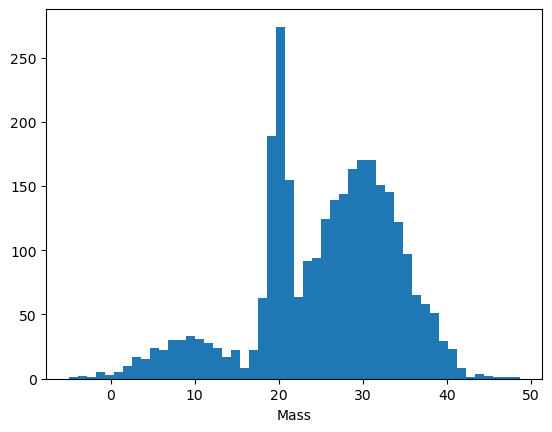

In [38]:
plt.hist(data, bins=50)
plt.xlabel('Mass')

In [47]:
gm = sklearn.mixture.GaussianMixture(n_components=3, random_state=0).fit(data)
aic = gm.aic(data)

In [48]:
print(gm.means_, aic)

[[30.12430964]
 [20.05198472]
 [ 9.09213997]] 20083.309155309096


In [51]:
means = []
weights = []
covariances =[]
aics = []
for n in range(1,11):
    gm_n = sklearn.mixture.GaussianMixture(n_components=n, random_state=0).fit(data)
    means.append(gm_n.means_)
    weights.append(gm_n.weights_)
    covariances.append(gm_n.covariances_)
    #print(gm_n.means_, gm_n.n_iter_)
    aic_n = gm_n.aic(data)
    print(aic_n)
    aics.append(aic_n)

20945.9726085902
20754.158751877432
20083.309155309096
20101.600433331412
20114.095745675375
20122.766659116478
20131.590157331997
20128.15439190298
20134.03432161794
20141.90627310284


30.124309639650438


[]

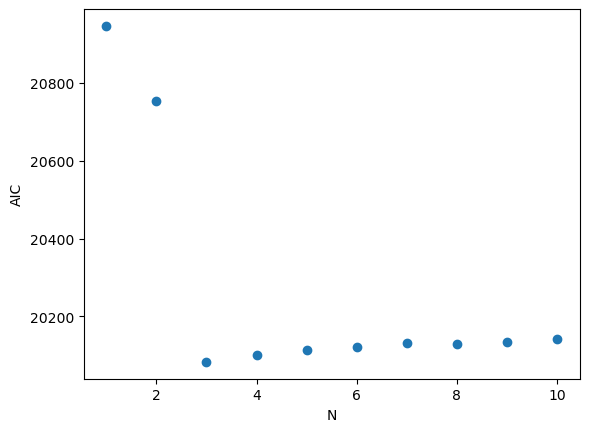

In [83]:
plt.scatter(range(1,11),aics)
index = np.argmin(aics)
best_mean = np.reshape(means[index],len(means[index]))
best_weight = np.reshape(weights[index],len(means[index]))
best_cov = np.reshape(covariances[index],len(means[index]))
print(best_mean[0])
plt.xlabel('N')
plt.ylabel('AIC')
plt.plot()

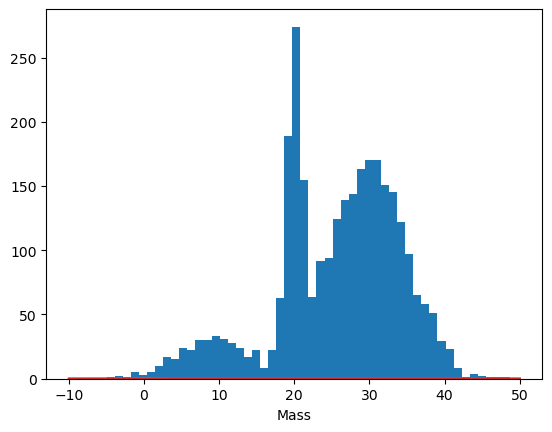

In [87]:
plt.hist(data, bins=50)
plt.xlabel('Mass')
x = np.linspace(-10,50,1000)
for i in range(len(best_mean)):
    gaus_i = norm(loc=best_mean[i],scale=best_cov[i])
    plt.plot(x,best_weight[i]*norm.pdf(x))
